# 04 Model Training

Objective: Train and tune machine learning models (e.g., XGBoost, LSTM) for BTC trend prediction.

In [2]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, classification_report, confusion_matrix

In [3]:

# --- STEP 1: Load the Vault Data ---
df = pd.read_csv(r'C:\Users\David\BTC-trend-prediction\data\processed\btc_alpha_v5.csv', parse_dates=['Date'])

# --- STEP 2: Define Features (X) and Target (y) ---
# CRITICAL: We MUST drop 'Next_Day_Return' because it is literally tomorrow's data. 
# If the model sees it, it achieves 100% accuracy by cheating.

X = df.drop(columns=['Date', 'Target'])
y = df['Target']

# --- STEP 3: Chronological Split (No Time Travel) ---
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} days. Testing on {len(X_test)} days.")

# --- STEP 4: Standardize the Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Training on 2194 days. Testing on 549 days.


In [4]:
# --- STEP 5: Initialize and Train the Brain ---
# max_depth=5 stops the tree from growing too deep and memorizing the noise
# random_state=42 ensures we get the exact same results every time we run this cell
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, min_samples_split=10)

print("Training model... (This might take a few seconds depending on your CPU)")
model.fit(X_train_scaled, y_train)

# --- STEP 6: Make Predictions on the Unseen Future (Test Set) ---
y_pred = model.predict(X_test_scaled)

# --- STEP 7: Evaluate Precision ---
precision = precision_score(y_test, y_pred)
print("\n--- RESULTS ---")
print(f"Model Precision: {precision * 100:.2f}%")

# Let's look at the exact breakdown
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training model... (This might take a few seconds depending on your CPU)

--- RESULTS ---
Model Precision: 48.61%

Confusion Matrix:
[[225  74]
 [180  70]]


C:\Users\David\AppData\Local\Temp\ipykernel_18004\3609316454.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


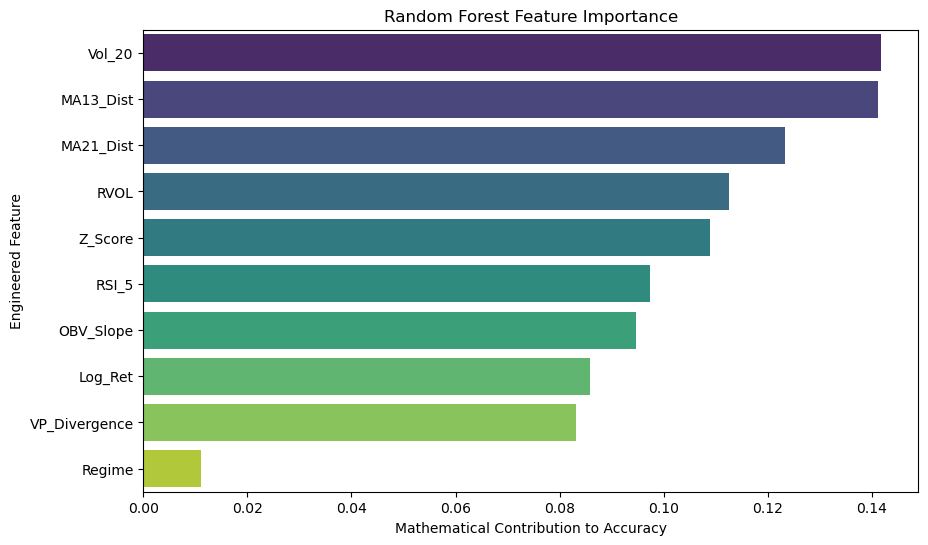

         Feature  Importance
1         Vol_20    0.141875
2      MA13_Dist    0.141229
3      MA21_Dist    0.123300
6           RVOL    0.112496
4        Z_Score    0.108848
5          RSI_5    0.097328
8      OBV_Slope    0.094623
0        Log_Ret    0.085927
7  VP_Divergence    0.083247
9         Regime    0.011127


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Extract the ML Logic ---
# The model remembers which features actually helped it reduce errors.
importances = model.feature_importances_

# Bind the numbers back to the column names
feature_names = X.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values('Importance', ascending=False)

# --- STEP 2: Visualize the Truth ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Mathematical Contribution to Accuracy')
plt.ylabel('Engineered Feature')
plt.show()

print(feature_imp_df)

<Axes: >

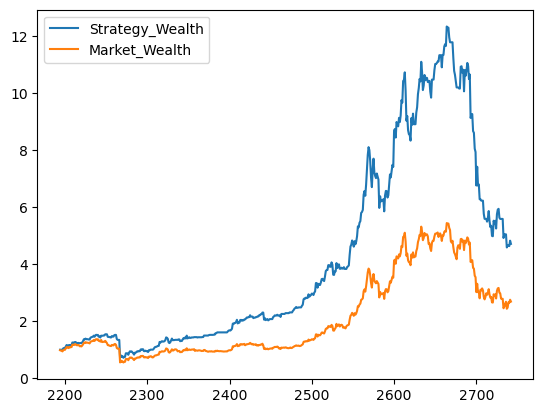

In [12]:
# Create the backtest dataframe and RESET the index to align everything
backtest_df = X_test.copy()

# This is the "Magic" line to fix your KeyError:
# We find the returns for the EXACT dates used in X_test
backtest_df['Actual_Return'] = df.loc[X_test.index, 'Log_Ret'].values

# Probabilities
backtest_df['Prob_Up'] = model.predict_proba(X_test_scaled)[:, 1]

# Signal (Use 0.52 to be safe)
backtest_df['Signal'] = (backtest_df['Prob_Up'] > 0.3).astype(int)

# Growth of $1
backtest_df['Strategy_Wealth'] = (1 + (backtest_df['Signal'] * backtest_df['Actual_Return'])).cumprod()
backtest_df['Market_Wealth'] = (1 + backtest_df['Actual_Return']).cumprod()

backtest_df[['Strategy_Wealth', 'Market_Wealth']].plot()

<Axes: title={'center': 'Regime-Aware Alpha Strategy'}>

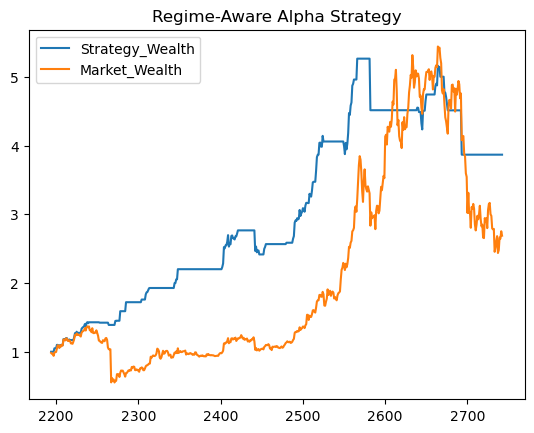

In [10]:
# 1. Add the Regime column back to your X_test for filtering
backtest_df = X_test.copy()
backtest_df['Regime'] = df.loc[X_test.index, 'Regime']
backtest_df['Actual_Return'] = df.loc[X_test.index, 'Log_Ret']
backtest_df['Prob_Up'] = model.predict_proba(X_test_scaled)[:, 1]

# 2. APPLY THE ALPHA FILTER
# In Bull markets (Regime 1), we use a standard 0.52 threshold
# In Bear markets (Regime 0), we use a strict 0.70 threshold to avoid traps
backtest_df['Signal'] = 0
backtest_df.loc[(backtest_df['Regime'] == 1) & (backtest_df['Prob_Up'] > 0.4), 'Signal'] = 1
backtest_df.loc[(backtest_df['Regime'] == 0) & (backtest_df['Prob_Up'] > 0.70), 'Signal'] = 1

# 3. Calculate Returns
backtest_df['Strategy_Wealth'] = (1 + (backtest_df['Signal'] * backtest_df['Actual_Return'])).cumprod()
backtest_df['Market_Wealth'] = (1 + backtest_df['Actual_Return']).cumprod()

backtest_df[['Strategy_Wealth', 'Market_Wealth']].plot(title="Regime-Aware Alpha Strategy")

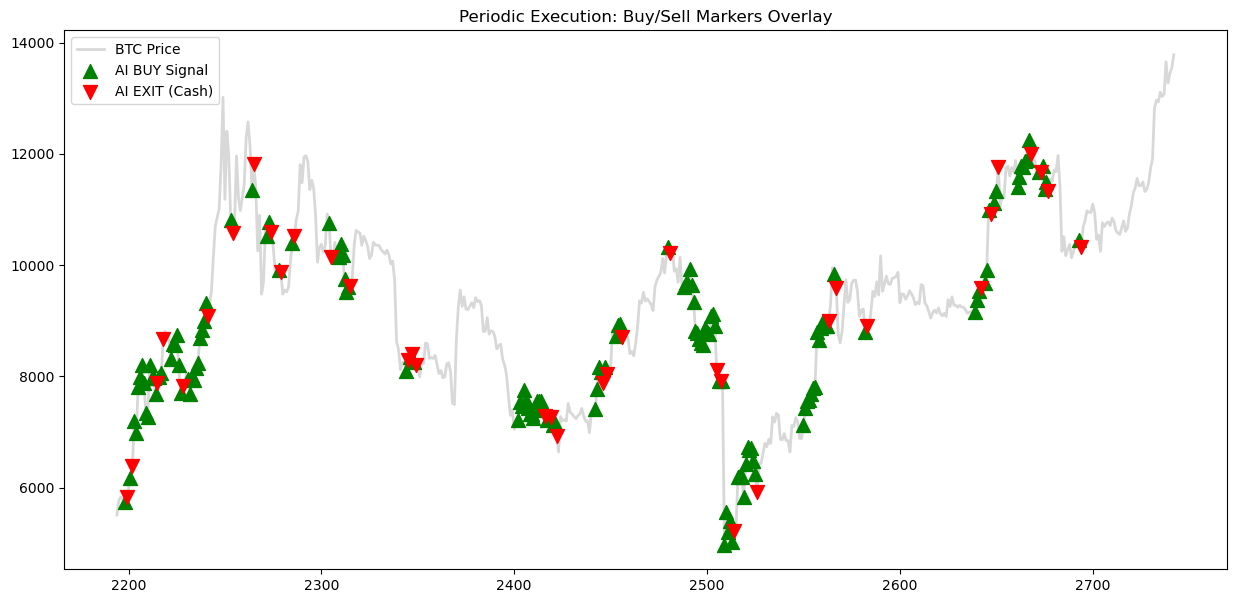

In [11]:
import matplotlib.pyplot as plt

# --- STEP 1: Get the Price back from Raw Data ---
# We load a temp version so we don't interfere with your processed features
df_raw = pd.read_csv(r'C:\Users\David\BTC-trend-prediction\data\raw\coin_Bitcoin.csv')
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

# Align the Close price to backtest_df using the original indices
# We use .loc to make sure the dates/rows match exactly
backtest_df['Close'] = df_raw.loc[backtest_df.index, 'Close'].values

# --- STEP 2: Zoom into the Period (Last 100 days) ---
zoom_df = backtest_df.tail(5000)

plt.figure(figsize=(15, 7))
plt.plot(zoom_df.index, zoom_df['Close'], label='BTC Price', color='gray', alpha=0.3, linewidth=2)

# --- STEP 3: Overlay the Periodic Buy Signals ---
buys = zoom_df[zoom_df['Signal'] == 1]
plt.scatter(buys.index, buys['Close'], marker='^', color='green', s=100, label='AI BUY Signal', zorder=5)

# --- STEP 4: Overlay the Exits ---
exits = zoom_df[(zoom_df['Signal'].shift(1) == 1) & (zoom_df['Signal'] == 0)]
plt.scatter(exits.index, exits['Close'], marker='v', color='red', s=100, label='AI EXIT (Cash)', zorder=5)

plt.title("Periodic Execution: Buy/Sell Markers Overlay")
plt.legend()
plt.show()